# STEP 1

# Import libraries

In [8]:
import matplotlib.pyplot as plt
import dhnx
import pandas as pd
import oemof.solph
from pyomo.environ import SolverFactory

## 1.1 Create network and plot

In [9]:
import os

# Initialize thermal network
network = dhnx.network.ThermalNetwork()

# Clean town data folder - macOS creates a hidden .DS_Store file that can interfere with data loading
twn_folder = r"DHNx_files/STEP_1/twn_data"
ds_store_twn = os.path.join(twn_folder, ".DS_Store")
if os.path.exists(ds_store_twn):
    os.remove(ds_store_twn)

# Load town parameter
network = network.from_csv_folder(twn_folder)

# Clean investment data folder - macOS creates a hidden .DS_Store file that can interfere with data loading
invest_folder = r"DHNx_files/STEP_1/invest_data"
ds_store_invest = os.path.join(invest_folder, ".DS_Store")
if os.path.exists(ds_store_invest):
    os.remove(ds_store_invest)

# Load investment parameter
invest_opt = dhnx.input_output.load_invest_options(invest_folder)


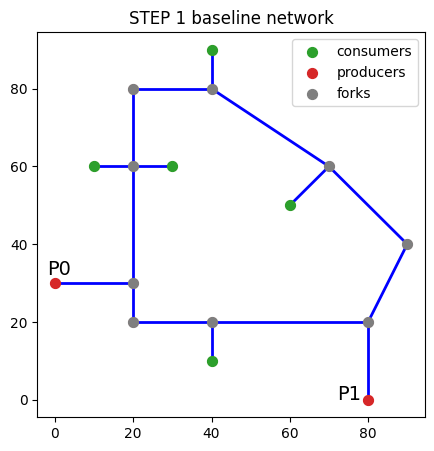

In [10]:
# plot initial/given network
static_map = dhnx.plotting.StaticMap(network) # That's how DHNx plots the network
static_map.draw(background_map=False) # This line to show the network on a blank area.
plt.title('STEP 1 baseline network') 

#Scatter plots to differentiate the consumers, producers and forks. 
plt.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
            color='tab:green', label='consumers', zorder=2.5, s=50) 
plt.scatter(network.components.producers['lon'], network.components.producers['lat'],
            color='tab:red', label='producers', zorder=2.5, s=50)
plt.scatter(network.components.forks['lon'], network.components.forks['lat'],
            color='tab:grey', label='forks', zorder=2.5, s=50)
plt.text(-2, 32, 'P0', fontsize=14)
plt.text(72, 0, 'P1', fontsize=14)
plt.legend()
plt.show()

## 1.2 Investment optimization of the network

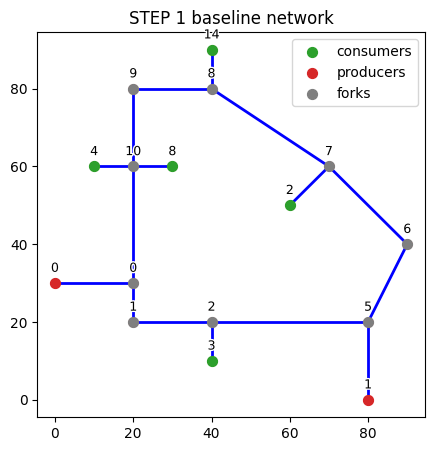

In [11]:
import matplotlib.pyplot as plt
# Add the required import for path effects
import matplotlib.patheffects as pe


# Define the helper function to plot points with labels
def scatter_with_labels(df, color, label):
    # Scatter plot for the points
    plt.scatter(df['lon'], df['lat'], color=color, label=label, zorder=2.5, s=50)
    
    # Determine which ID to use (column 'id' if it exists, otherwise the index)
    ids = df['id'] if 'id' in df.columns else df.index
    
    # Add labels (annotations) above each point
    for _id, x, y in zip(ids, df['lon'], df['lat']):
        plt.annotate(
            str(_id), (x, y),
            xytext=(0, 6), textcoords='offset points',  # Position slightly above the point
            ha='center', va='bottom', fontsize=9, zorder=3,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')]  # White outline for readability
        )

## plot initial/given network
static_map = dhnx.plotting.StaticMap(network)
static_map.draw(background_map=False) 
plt.title('STEP 1 baseline network') 

# Use the new function to plot the nodes with labels
scatter_with_labels(network.components.consumers, 'tab:green', 'consumers')
scatter_with_labels(network.components.producers, 'tab:red', 'producers')
scatter_with_labels(network.components.forks,     'tab:grey', 'forks')

plt.legend()
plt.show()

In [12]:
# Execute investment optimization
network.optimize_investment(invest_options=invest_opt, write_lp_file=True, solver='glpk')

INFO:dhnx.optimization.optimization_models:Initialize the energy system
INFO:dhnx.optimization.optimization_models:Create oemof objects
INFO:dhnx.optimization.optimization_models:Producers, Consumers Nodes appended.
/opt/anaconda3/envs/env_P2/lib/python3.9/site-packages/oemof/solph/flows/_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
/opt/anaconda3/envs/env_P2/lib/python3.9/site-packages/oemof/network/network/nodes.py:250: FutureWarning: Usage of oemof.network.Component is deprecated. Use oemof.network.Node instead.
  warnings.warn(
INFO:dhnx.optimization.optimization_models:DHS Nodes appended.
INFO:dhnx.optimization.optimization_models:Energysystem has been created
INFO:dhnx.optimization.optimization_models:Build the operational model
INFO:dhnx.optimization.optimization_models:Solve the optimization problem


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmpa65vuu9v.glpk.raw
 --wglp /var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp1ocbrhb4.glpk.glp
 --cpxlp /var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmpx1r_j43e.pyomo.lp
Reading problem data from '/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmpx1r_j43e.pyomo.lp'...
/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmpx1r_j43e.pyomo.lp:2962: warning: lower bound of variable 'x52' redefined
/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmpx1r_j43e.pyomo.lp:2962: warning: upper bound of variable 'x52' redefined
466 rows, 402 columns, 1052 non-zeros
50 integer variables, all of which are binary
3012 lines were read
Writing problem data to '/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp1ocbrhb4.glpk.glp'...
2580 lines were written
GLPK Integer Optimizer 5.0
466 rows, 402 columns, 1052 non-zeros
50 integer variables, all of which are binary

INFO:root:Optimization successful...
INFO:dhnx.optimization.optimization_models:Store lp-file in /Users/michelangeloinze/.oemof/lp_files/DHNx.lp


## 1.3 Results postprocessing and Plotting 


      from_node       to_node hp_type  capacity  direction      costs  losses
id                                                                           
0   producers-0       forks-0   DN-50   486.104          1  16121.040   0.182
1   producers-1       forks-5    None     0.000          0      0.000   0.000
2       forks-0       forks-1   DN-32    74.344          1   5281.720   0.086
3       forks-1       forks-2   DN-32    74.258          1  10562.580   0.172
4       forks-2       forks-5    None     0.000          0      0.000   0.000
7       forks-5       forks-6    None     0.000          0      0.000   0.000
8       forks-6       forks-7    None     0.000          0      0.000   0.000
9       forks-7       forks-8   DN-32    53.000         -1  15525.000   0.258
10      forks-8       forks-9   DN-50   201.612         -1  13276.120   0.182
11      forks-9      forks-10   DN-50   201.703         -1   6638.515   0.091
12     forks-10       forks-0   DN-50   411.578         -1  2306

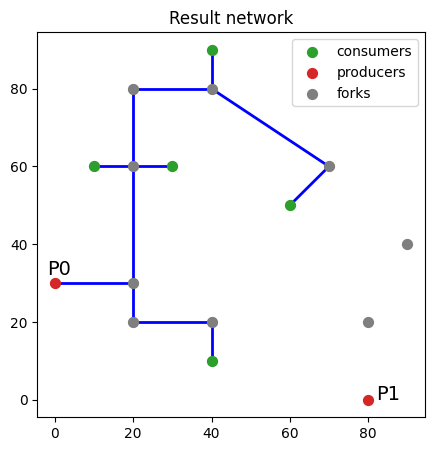

In [13]:
# ####### Postprocessing and Plotting ###########
results_edges = network.results.optimization['components']['pipes']
print(results_edges[['from_node', 'to_node', 'hp_type', 'capacity',
                     'direction', 'costs', 'losses']])

results_edges.to_csv("Outputs/STEP_1.results_edges.csv", index=True)

print('Objective value: ', network.results.optimization['oemof_meta']['objective'])

# assign new ThermalNetwork with invested pipes
twn_results = network
twn_results.components['pipes'] = results_edges[results_edges['capacity'] > 0.001]

# plot invested edges
static_map_2 = dhnx.plotting.StaticMap(twn_results)
static_map_2.draw(background_map=False)
plt.title('Result network')
plt.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
            color='tab:green', label='consumers', zorder=2.5, s=50)
plt.scatter(network.components.producers['lon'], network.components.producers['lat'],
            color='tab:red', label='producers', zorder=2.5, s=50)
plt.scatter(network.components.forks['lon'], network.components.forks['lat'],
            color='tab:grey', label='forks', zorder=2.5, s=50)
plt.text(-2, 32, 'P0', fontsize=14)
plt.text(82, 0, 'P1', fontsize=14)
plt.legend()
plt.show()

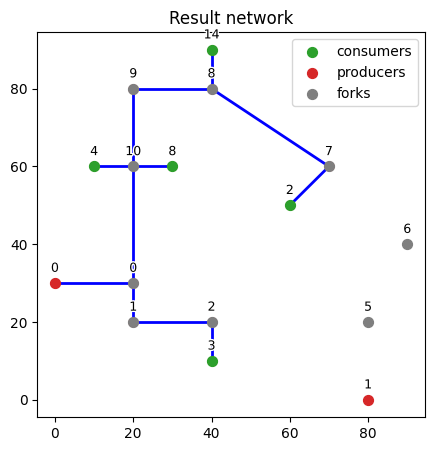

In [14]:
# Define the helper function to plot points with labels
def scatter_with_labels(df, color, label):
    # scatter plot for the points
    plt.scatter(df['lon'], df['lat'], color=color, label=label, zorder=2.5, s=50)
    
    # Determine which ID to use (column 'id' if it exists, otherwise the index)
    ids = df['id'] if 'id' in df.columns else df.index
    
    # Add labels (annotations) above each point
    for _id, x, y in zip(ids, df['lon'], df['lat']):
        plt.annotate(
            str(_id), (x, y),
            xytext=(0, 6), textcoords='offset points',  # Position slightly above the point
            ha='center', va='bottom', fontsize=9, zorder=3,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')]  # White outline for readability
        )

# plot invested edges
static_map_2 = dhnx.plotting.StaticMap(twn_results)
static_map_2.draw(background_map=False)
plt.title('Result network')

# Use the function to plot the nodes with labels, replacing the manual scatter and text calls
scatter_with_labels(network.components.consumers, 'tab:green', 'consumers')
scatter_with_labels(network.components.producers, 'tab:red', 'producers')
scatter_with_labels(network.components.forks,     'tab:grey', 'forks')

plt.legend()
plt.show()

### How does the optimizer decide which pipe type to use in different parts of the network?

The network optimization model is formulated as a mixed-integer problem that minimizes total system costs (investment plus operation) subject to demand that needs to be matched, capacity, and flow constraints.

### What is the difference between the selected pipes in terms of cost, thermal losses, and capacity?


The DN-50 pipe is used for the main branch and has high capacity, high cost, and high thermal losses, while the DN-32 is used for smaller branches, costs less, and has lower thermal losses.

### Why the optimizer might favor one type of pipe near the beginning of the network or another type elsewhere

In order to reduce the cost and optimize the network with higher efficiency, the DN-50 pipe is selected for the main branch with high capacity to supply more consumers. The DN-32 pipe is selected for the small branch with smaller capacity where the load is lower